In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob

In [2]:
from arcgis.gis import GIS
gis = GIS("http://deldev.maps.arcgis.com", "demos_deldev", "DelDevs12")

In [3]:
from arcgis.features.summarize_data import join_features

In [4]:
item1 = gis.content.get('87b758aaf694473eb98ac12f3caba5fc')

<Item title:"Traffic Accident Locations" type:Feature Layer Collection owner:JohnsCreekGA>
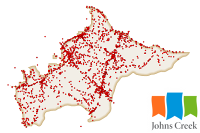

In [5]:
item1

In [6]:
item2 = gis.content.get('347e78364333497eb9cbb428b963015a')

<Item title:"parcels" type:Feature Layer Collection owner:demos_deldev>
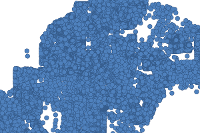

In [7]:
item2

In [8]:
test = join_features(target_layer=item2.layers[0],
                     join_layer=item1.layers[0],
                     spatial_relationship='withindistance',
                     spatial_relationship_distance=500,
                     spatial_relationship_distance_units='Meters',
                     context={"extent":{"xmin":-9375809.87305117,"ymin":4031882.3806860778,"xmax":-9370182.196843527,"ymax":4034872.9794178144,"spatialReference":{"wkid":102100,"latestWkid":3857}}})

In [9]:
assert isinstance(test, FeatureCollection)
test

<FeatureCollection>

In [10]:
item3 = gis.content.get('d7df3bc55138483282757592c5650e25')

<Item title:"Address Points" type:Feature Layer Collection owner:JohnsCreekGA>
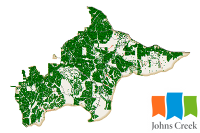

In [11]:
item3

In [12]:
from datetime import datetime
test = join_features(target_layer=item3.layers[0],
                     join_layer=item1.layers[0],
                     attribute_relationship=[{"targetField":"City","operator":"equal","joinField":"City"}],
                     join_operation='JoinOneToMany',
                     output_name='join using attribute' + str(datetime.now().microsecond),
                     context={"extent":{"xmin":-9375081.009062584,"ymin":4034056.5450066775,"xmax":-9372267.170958761,"ymax":4035062.169660081,"spatialReference":{"wkid":102100,"latestWkid":3857}}})

In [13]:
assert isinstance(test, Item)
test

<Item title:"join using attribute445069" type:Feature Layer Collection owner:demos_deldev>

In [14]:
test.delete()

True

In [ ]:
test = join_features(target_layer=item2.layers[0],
                     join_layer=item1.layers[0],
                     future=True,
                     spatial_relationship='intersects',
                     context={"extent":{"xmin":-9375809.87305117,"ymin":4031882.3806860778,"xmax":-9370182.196843527,"ymax":4034872.9794178144,"spatialReference":{"wkid":102100,"latestWkid":3857}}})

In [ ]:
assert isinstance(test, GPJob)
test.result()